* For the purposes of this preliminary work, code packages have been developed and are utilized as libraries within the notebook workflow.
* A variables dictionary can be found at [Gaia Source](https://gaia.aip.de/metadata/gaiadr3/gaia_source/)
* The [github page of the project](https://github.com/kokorikos212/Data-Science-and-Applications-2026/tree/main/our_work).

In [3]:
if True:
  import importlib
  import DatasetBuilder
  import visualisation_mod
  import EDA
  import pandas as pd
  import numpy as np
  import torch

  # Force a fresh load of both modules
  importlib.reload(DatasetBuilder)
  importlib.reload(visualisation_mod)
  importlib.reload(EDA)


  from EDA import ExploratoryAnalyzer
  from DatasetBuilder import MultimodalDatasetFactory, MultimodalUniverseFactory
  from visualisation_mod import UniverseVisualizer


  DATA_ROOT = "/content/drive/MyDrive/Data_science_and_applications"
  factory = MultimodalUniverseFactory(base_path=DATA_ROOT)
  print("✓ Modules synced and ready.")

✓ Modules synced and ready.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
def plot_distributions(df, cols=["phot_g_mean_mag"]):
    """
    Plots distributions for specific columns.
    Defaults to 'abs_mag' if no list is provided.
    """
    for col in cols:
        if col in df.columns:
            sns.displot(df[col], kde=True, aspect=1.5)
            plt.title(f"Distribution of {col}")
            plt.show()
        else:
            print(f"Column '{col}' not found in dataset.")

### Data Import and Encoding

As part of the **"Data Science and Applications" (CS485)** course, this project focuses on the analysis of astronomical data retrieved from the **Multimodal Universe** platform.

* **Research Objective:** The core question of this study is the approximation of a star's **Absolute Magnitude ($M$)** in cases where certain parameters are difficult to measure accurately or are missing altogether. Our goal is to derive a new variable that effectively substitutes the independent variables in the absolute magnitude equation using regression models.
* **Data and Variables:** We utilize data from the **Gaia survey**, focusing on the following parameters:
    * $m$ (**Apparent Magnitude**): The observed brightness (`phot_g_mean_mag`).
    * $p$ (**Parallax**): The parallax measured in milliarcseconds (mas).

### Theoretical Challenge and Model Architecture

Our colleagues in the astronomy department have challenged us to approximate a fundamental physical relationship they use daily:
$$M = m - 5 \log_{10}(d) + 5$$

It is worth noting that parallax measurements often carry significant observational errors or even negative values for distant objects. This makes the logarithmic term in the equation mathematically unstable. By using a Neural Network, we aim to learn a robust mapping that can handle these analytical instabilities.

---------------Part 0 - Data Aquisition and Filtering ------------------


In [12]:
factory = MultimodalUniverseFactory(base_path="MultimodalUniverse/gaia")

df_gaia = factory.load_as_dataframe("MultimodalUniverse/gaia", n_samples=250)
df_gaia['abs_mag'] = df_gaia['phot_g_mean_mag'] + 5 + 5 * np.log10(df_gaia['parallax'] / 1000.0)

Opening stream to MultimodalUniverse/gaia...
Successfully fetched 250 examples via stream.
Successfully created DataFrame with shape: (250, 73)


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


(Fellow astronomer):Boy, that dataset does not contain only stars! You've got contaminants and unreliable astrometry in there!

In [ ]:
all_variables = df_gaia.columns.tolist()
df_gaia.describe()

,object_id,healpix,ra,dec,phot_g_mean_mag,phot_g_mean_flux,phot_g_mean_flux_error,phot_bp_mean_mag,phot_bp_mean_flux,phot_bp_mean_flux_error,...,teff_gspphot_upper,ruwe,ecl_lat,ecl_lon,nu_eff_used_in_astrometry,pseudocolour,astrometric_params_solved,rv_template_teff,grvs_mag,abs_mag
count,2.500000e+02,250.0,250.000000,250.000000,250.000000,2.500000e+02,250.000000,250.000000,2.500000e+02,250.000000,...,232.000000,249.000000,250.000000,250.000000,248.000000,1.000000,250.000000,67.000000,66.000000,248.000000
mean,4.816502e+13,0.0,45.024903,0.472381,15.586965,1.541679e+05,62.414861,16.183444,7.707946e+04,81.387243,...,4995.647140,1.337507,-15.891450,42.704569,1.463208,1.285669,31.144000,5258.208955,12.271604,5.820490
std,2.831651e+13,0.0,0.287223,0.185804,1.849637,8.548461e+05,318.900072,1.978973,4.081921e+05,425.356424,...,1287.004015,1.609398,0.178428,0.303386,0.088790,NaN,4.424655,1038.997077,1.677288,2.201005
min,4.295807e+09,0.0,44.347668,0.005615,8.068802,5.755077e+02,1.915766,8.554075,3.185234e+02,3.905183,...,3435.402344,0.850041,-16.329575,42.070763,1.249905,1.285669,3.000000,3500.000000,7.174999,-5.151599
25%,2.008756e+13,0.0,44.793941,0.337155,14.913305,3.433735e+03,2.988956,15.456477,1.296120e+03,12.434886,...,4370.207886,0.989001,-16.024553,42.463692,1.401820,1.285669,31.000000,4625.000000,11.584083,4.660817
50%,5.150954e+13,0.0,45.051355,0.494011,16.013763,7.403582e+03,4.373670,16.657527,2.967637e+03,15.666491,...,4998.954834,1.030815,-15.886818,42.674387,1.483192,1.285669,31.000000,5250.000000,13.043884,5.765827
75%,7.318624e+13,0.0,45.256028,0.618650,16.847957,2.040170e+04,9.185114,17.556932,8.970767e+03,22.932981,...,5454.418945,1.091646,-15.739901,42.935192,1.532099,1.285669,31.000000,5750.000000,13.467542,7.216375
max,9.573053e+13,0.0,45.676891,0.868359,18.787239,1.115388e+07,3210.559082,19.080688,5.173526e+06,5383.515625,...,19276.490234,21.098814,-15.535777,43.392708,1.765242,1.285669,95.000000,11000.000000,13.943413,10.812217


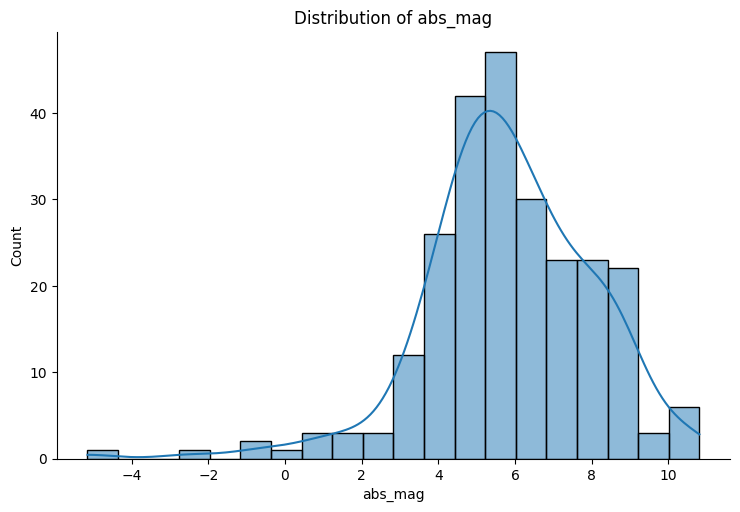

In [ ]:
plot_distributions(df_gaia, ["abs_mag"])

### Data Retrieval and Filtering Mechanism

We have upgraded the loading mechanism to ensure that the final feature matrix $X \in \mathbb{R}^{n \times d}$ contains exactly the sample size $n$ specified by the user.

* **Batch-Level Filtering:** The filtering process is executed immediately after retrieving each batch, but before the data is appended to the main DataFrame.
* **Feature Selection:** We employ a filtering tool to retain only the variables typically used by astronomers to calculate absolute magnitude.
* **Key Variables:** * `phot_g_mean_mag` ($m$)
    * `parallax` ($p$)
    * `bp_rp` (Color index)

#### Data Pre-processing
To ensure the integrity of the regression model, we perform the following cleaning steps:
1. **Handling Missing Values:** Removal of all samples containing null values (NaN).
2. **Physical Constraints:** Removal of samples with negative parallax values to maintain mathematical and physical consistency.

In [ ]:
pipeline = ['_apply_star_filters', '_filter_completeness','_apply_star_filters']

df_filtered = factory.load_validated_dataset(
    path="MultimodalUniverse/gaia",
    n_wanted=500,
    batch_size=100,
    filter_names=pipeline
)

print(f"Acquisition complete. Final dataset contains {len(df_filtered)} validated stars.")

In [9]:
df_filtered.describe()

,object_id,healpix,ra,dec,phot_g_mean_mag,phot_g_mean_flux,phot_g_mean_flux_error,phot_bp_mean_mag,phot_bp_mean_flux,phot_bp_mean_flux_error,...,teff_gspphot_upper,ruwe,ecl_lat,ecl_lon,nu_eff_used_in_astrometry,pseudocolour,astrometric_params_solved,rv_template_teff,grvs_mag,abs_mag
count,5.000000e+02,500.0,500.000000,500.000000,500.000000,5.000000e+02,500.000000,500.000000,5.000000e+02,500.000000,...,479.000000,500.000000,500.000000,500.000000,495.000000,5.000000,500.000000,120.000000,118.000000,500.000000
mean,1.008979e+14,0.0,45.226915,0.715938,15.727033,1.686831e+05,99.923896,16.322775,7.594670e+04,144.588448,...,4937.478967,1.032731,-15.716967,42.979111,1.466469,1.350202,31.640000,5233.750000,12.284183,5.874666
std,5.454334e+13,0.0,0.479414,0.279514,1.801699,1.225702e+06,1351.242706,1.918398,5.149440e+05,1572.578458,...,836.337059,0.086941,0.230624,0.524251,0.088992,0.191117,6.374297,941.283821,1.670188,2.265014
min,4.295807e+09,0.0,44.347668,0.005615,7.475046,2.176878e+02,1.488148,8.025092,6.614730e+01,3.905183,...,3070.924561,0.812695,-16.329575,42.070763,1.211880,1.091476,31.000000,3400.000000,6.340329,-5.151599
25%,5.889367e+13,0.0,44.869111,0.529341,15.034873,3.043007e+03,2.761158,15.565137,1.118542e+03,12.344025,...,4404.969238,0.982016,-15.875492,42.567996,1.406615,1.231498,31.000000,4750.000000,11.604308,4.553090
50%,1.032553e+14,0.0,45.117426,0.735055,16.168814,6.419045e+03,3.990270,16.752766,2.718396e+03,15.487194,...,5011.344727,1.023054,-15.689221,42.848963,1.492007,1.369583,31.000000,5250.000000,12.900395,5.675020
75%,1.447350e+14,0.0,45.545911,0.909066,16.979136,1.824286e+04,7.475928,17.716912,8.116428e+03,22.655905,...,5479.197510,1.065934,-15.547415,43.326686,1.533305,1.511927,31.000000,5750.000000,13.454550,7.216375
max,2.003516e+14,0.0,46.374786,1.307179,19.842781,1.927208e+07,29694.367188,20.787262,8.421320e+06,33184.554688,...,12370.715820,1.398988,-15.218068,44.257793,1.766054,1.546524,95.000000,11000.000000,14.074693,15.135254


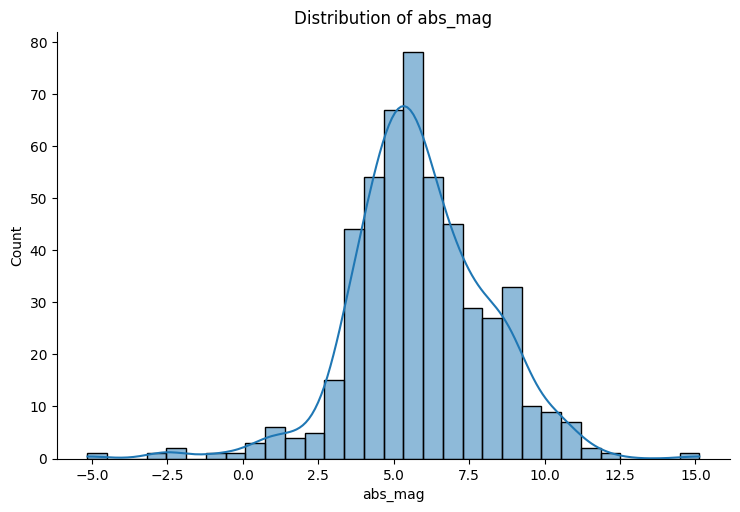

In [10]:
plot_distributions(df_filtered, ['abs_mag'])

### Visualizing the "Astronomer's Filter"

For demonstration purposes, the distributions of the variables before and after applying the **"Astronomer's Filter"** are compared below.

To quantify the difference between the initial (unfiltered) data stream and our verified stellar sample, we calculate the **Kolmogorov-Smirnov (K-S) Statistic**. This allows us to statistically measure how much the distribution has shifted after removing non-physical values and outliers.

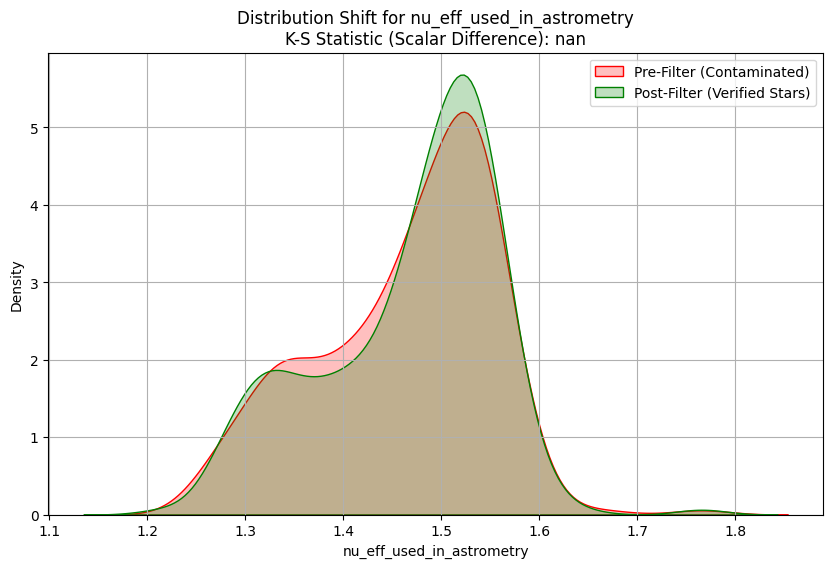

In [14]:
def demonstrate_filter_impact(df_raw, df_filtered, column='abs_mag'):
    """
    Calculates the K-S statistic to represent the difference between
    distributions and visualizes the change.
    """
    from scipy.stats import ks_2samp
    # 1. Calculate the Scalar Difference (K-S Statistic)
    # The result 'd_stat' is a scalar between 0 and 1
    d_stat, p_value = ks_2samp(df_raw[column].dropna(), df_filtered[column])

    # 2. Visualization
    plt.figure(figsize=(10, 6))
    sns.kdeplot(df_raw[column], label='Pre-Filter (Contaminated)', fill=True, color='red')
    sns.kdeplot(df_filtered[column], label='Post-Filter (Verified Stars)', fill=True, color='green')

    plt.title(f"Distribution Shift for {column}\nK-S Statistic (Scalar Difference): {d_stat:.4f}")
    plt.xlabel(column)
    plt.ylabel("Density")
    plt.legend()
    plt.grid()
    plt.show()

    return d_stat

ruwe_diff = demonstrate_filter_impact(df_gaia, df_filtered, column='nu_eff_used_in_astrometry')

#### The `DistanceModulusNet`
To address this, we have designed a Multi-Layer Perceptron (MLP) specifically for this regression task.

* **Input Layer:** Receives 2 features ($m$ and $p$).
* **Hidden Layers:** Utilize **ReLU** activation functions. These are essential for capturing the non-linear logarithmic behavior of the parallax within the distance modulus formula.
* **Output Layer:** A single continuous value representing the predicted **Absolute Magnitude ($M$)**

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [16]:
X_raw = df_filtered[['phot_g_mean_mag', 'parallax']].values
y_raw = df_filtered['abs_mag'].values.reshape(-1, 1)

# (80/20)
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_np)
X_test_scaled = scaler.transform(X_test_np)

X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test = torch.tensor(y_test_np, dtype=torch.float32)

print(f"Scaled X_train sample:\n{X_train[:3]}")
print(f"Target y_train sample:\n{y_train[:3]}")

Scaled X_train sample:
tensor([[ 0.8982, -0.7409],
        [ 0.5758, -0.7236],
        [-0.9432,  2.2853]])
Target y_train sample:
tensor([[3.9689],
        [3.7226],
        [8.0399]])


In [17]:
class DistanceModulusNet(nn.Module):
    """
    A simple neural network to approximate the distance modulus equation.
    It learns the mapping from (m, p) -> M.
    """
    def __init__(self):
        super(DistanceModulusNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(2, 16),      # Input: m, parallax
            nn.ReLU(),             # Non-linear activation to capture log(p)
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)        # Output: Predicted abs_mag
        )
    def forward(self, x):
        return self.network(x)

    def save_weights(self, path: str = "distance_model.pth"):
        """Saves the learned internal weights (state_dict) to disk."""
        torch.save(self.state_dict(), path)
        print(f"Model weights successfully saved to {path}")

    @staticmethod
    def load_from_weights(path: str):
        """Creates a new model instance and populates it with saved weights."""
        model = DistanceModulusNet()
        model.load_state_dict(torch.load(path))
        model.eval()  # Set to evaluation mode by default after loading
        print(f"Model loaded from {path} and set to evaluation mode.")
        return model

In [18]:
model1 = DistanceModulusNet()
criterion = nn.MSELoss() # Mean Squared Error
optimizer = optim.Adam(model1.parameters(), lr=0.01)

In [19]:
epochs = 1500
train_losses = []

for epoch in range(epochs):
    model1.train()
    optimizer.zero_grad()

    # Forward pass
    outputs = model1(X_train)
    loss = criterion(outputs, y_train)

    # Backward pass and optimization
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

print(f"Training completed with Loss: {train_losses[-1]}")

Training completed with Loss: 0.015941418707370758


In [20]:
# model1.save_weights("gaia_nn_v1.pth")
# fresh_model = DistanceModulusNet.load_from_weights("gaia_nn_v1.pth")
# from google.colab import files
# files.download('gaia_nn_v1.pth')

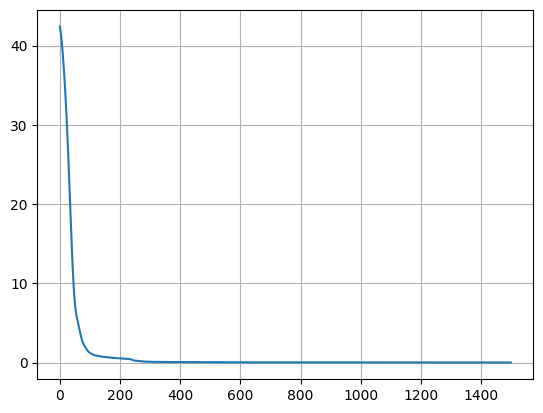

In [21]:
plt.plot(train_losses)
plt.grid()
plt.show()

/tmp/ipykernel_2452/4159256573.py:6: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  residuals = y_test - y_new_pred


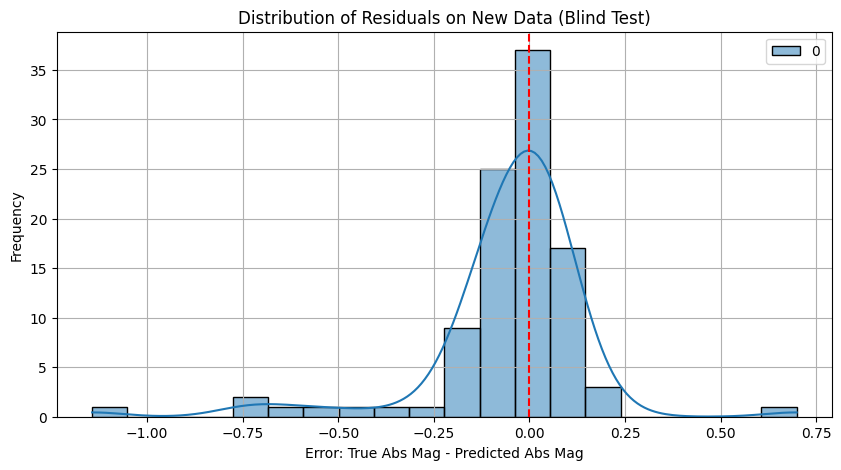

In [22]:
# Get model predictions
model1.eval()
with torch.no_grad():
    y_new_pred = model1(X_test).numpy()

residuals = y_test - y_new_pred

# the Distribution of Residuals
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='purple', bins=20)
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution of Residuals on New Data (Blind Test)')
plt.xlabel('Error: True Abs Mag - Predicted Abs Mag')
plt.ylabel('Frequency')
plt.grid()
plt.show()

We have a solid baseline. We now have a neural version of the physics. It’s our ground truth. Ready for the Real Test: Since the model can replicate the known formula ($M = m + 5 + 5 \log_{10}(p/1000)$), we can stop relying on distance ($d$) and start hunting for other variables that can do the same job.

-> Sensor Substitution: Using expensive sensors (Parallax/LIDAR) to train a model that eventually only uses cheap sensors (Color indices/RGB cameras).

Part 1 — Exploratory Data Analysis

---



## Feature Correlation Analysis (Feature Discovery)

In this section, we examine which of the available Gaia variables exhibit the greatest "alignment" with Absolute Magnitude ($M$) in multidimensional space.

### Methodology

* **Cosine Similarity:** We measure the angle between the vector of each feature and the target vector $\mathbf{y}$. A value near $1$ indicates that the variable "points" in the same direction as $M$.
    $$\cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|}$$

* **Inner Products:** We utilize tensor inner products to identify which features carry the most information regarding the variance of the target.
    $$\langle \mathbf{x}, \mathbf{y} \rangle = \sum_{i=1}^{n} x_i y_i$$

In [23]:
downloading_filters = ['_apply_star_filters', '_filter_completeness','_filter_outliers']

df_stars = factory.load_validated_dataset(
    path="MultimodalUniverse/gaia",
    n_wanted=2000,
    batch_size=100,
    filter_names=downloading_filters
)

print(f"Acquisition complete. Final dataset contains {len(df_stars)} validated stars.")

Acquisition complete. Final dataset contains 2000 validated stars.


In [24]:
def fast_statistical_cleanup(df, target_col):
    """
    Removing constant and sparse features
    using basic descriptive statistics.
    """
    numeric_df = df.select_dtypes(include=[np.number])

    variances = numeric_df.var()
    constant_features = variances[variances == 0].index.tolist()

    # (NaN Check) [cite: 18]
    null_counts = numeric_df.isnull().mean()
    sparse_features = null_counts[null_counts > 0.2].index.tolist()

    to_drop = list(set(constant_features + sparse_features))
    cleaned_df = numeric_df.drop(columns=to_drop)

    print(f"--- Statistical Cleanup Report ---")
    print(f" > Removed {len(constant_features)} constant features.")
    print(f" > Removed {len(sparse_features)} sparse features (too many NaNs).")
    print(f" > Remaining candidates for tensor analysis: {cleaned_df.shape[1]}")

    return cleaned_df

df_stars = fast_statistical_cleanup(df_stars, 'abs_mag')

--- Statistical Cleanup Report ---
 > Removed 1 constant features.
 > Removed 8 sparse features (too many NaNs).
 > Remaining candidates for tensor analysis: 63


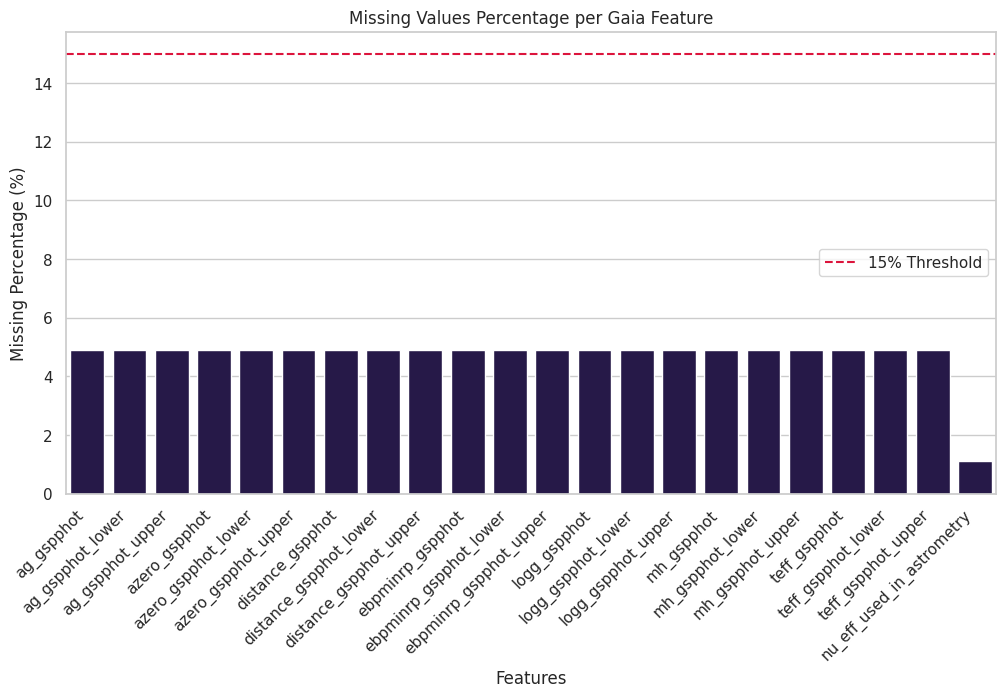

Data Profiling: 22 features contain missing values.


In [25]:
visualizer = UniverseVisualizer(df_stars)
visualizer.plot_missing_values(threshold=15)

In [26]:
len(df_stars.columns)

63

1.1 (EDA) Feature Selection
We will utilize the three parameters with the highest Mutual Information (MI) score that successfully passed the completeness filter:$$\mathcal{F} = \{ \text{phot_g_mean_mag}, \text{bp_rp}, \text{phot_bp_mean_flux_over_error} \}

The MI Score $I(X; Y)$ quantifies the statistical dependence between our candidate features and the target $M$. Unlike linear correlation, it captures non-linear relationships that our models can exploit.phot_g_mean_mag

In [27]:
from sklearn.feature_selection import mutual_info_regression

In [28]:
df_fs = df_stars.select_dtypes(include=[np.number]).dropna()
X_fs = df_fs.drop(columns=['abs_mag'])
y_fs = df_fs['abs_mag']

# CAlculation of Mutual Information
mi_scores = mutual_info_regression(X_fs, y_fs)
mi_results = pd.Series(mi_scores, index=X_fs.columns).sort_values(ascending=False)

print("Top Features by Mutual Information :")
print(mi_results.head(10))

Top Features by Mutual Information :
bp_rp                        1.333676
nu_eff_used_in_astrometry    1.310164
g_rp                         1.306621
bp_g                         1.282387
teff_gspphot_upper           1.167883
teff_gspphot                 1.153288
teff_gspphot_lower           1.141716
phot_bp_rp_excess_factor     1.085756
logg_gspphot_upper           0.548715
parallax                     0.529239
dtype: float64


bp_rp = Color Index:
The difference between the Blue Passband (BP) and Red Passband (RP) magnitudes. It serves as a primary proxy for stellar temperature.

phot_g_mean_mag = Apparent G-band Magnitude: The average brightness of the star as detected across the broad Gaia G-band. Used as the baseline for calculating absolute magnitude.

nu_eff_used_in_astrometry = Effective Wavenumber: The photon-weighted average wavenumber used in the astrometric solution. It accounts for chromatic shifts in the star's observed position.

Now we can re-initialise our dataset using a filter that guaranties complitness on our special parameters.

In [29]:
features = ['bp_rp','phot_g_mean_mag', 'nu_eff_used_in_astrometry']

df_stars_complete = factory.load_validated_dataset("MultimodalUniverse/gaia",n_wanted=5000, filter_names=downloading_filters, required_vars=features)

/tmp/ipykernel_2452/338809768.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.ax_joint.legend(title='Effective Wavenumber\n($\\nu_{eff}$)', title_fontsize=11)


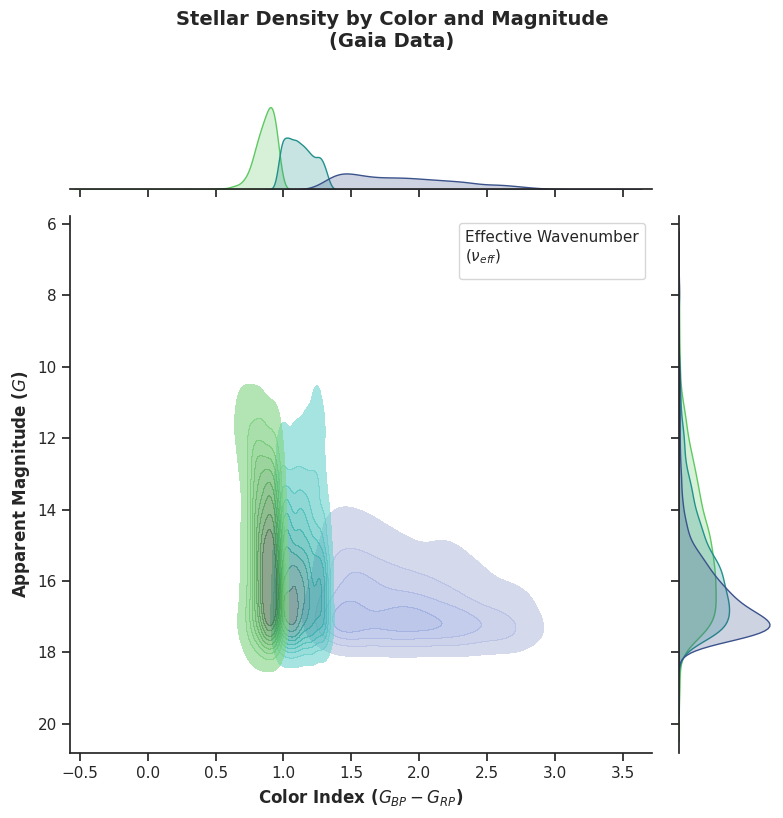

In [31]:
Gemini = True
if Gemini:
  # --- Προετοιμασία Δεδομένων (Αν δεν έχει γίνει ήδη) ---
  # Φιλτράρισμα NaNs για τις μεταβλητές που θα σχεδιάσουμε
  plot_cols = ['bp_rp', 'phot_g_mean_mag', 'nu_eff_used_in_astrometry']
  df_plot = df_stars_complete[plot_cols].dropna().copy()

  # Δημιουργία 3 κατηγοριών (bins) για το nu_eff για να λειτουργήσει το hue
  # (Χρησιμοποιούμε qcut για ισοπληθείς κατηγορίες: Low, Med, High)
  df_plot['nu_eff_bin'] = pd.qcut(
      df_plot['nu_eff_used_in_astrometry'],
      q=3,
      labels=["Low", "Med", "High"]
  )

  # --- Δημιουργία του Plot ---
  # Χρησιμοποιούμε theme "ticks" για καθαρότερη εμφάνιση
  sns.set_theme(style="ticks")

  g = sns.jointplot(
      data=df_plot,
      x="bp_rp",
      y="phot_g_mean_mag",
      hue="nu_eff_bin",
      kind="kde",        # Kernel Density Estimate (πυκνότητα)
      fill=True,         # Γέμισμα των καμπυλών πυκνότητας
      alpha=0.6,         # Διαφάνεια για να φαίνονται οι επικαλύψεις
      palette="viridis",  # Χρωματική παλέτα (κατάλληλη για Low/Med/High)
      height=8           # Μέγεθος του γραφήματος
  )

  # --- Αστρονομικές Προσαρμογές (Insights) ---

  # 1. Αντιστροφή του Y άξονα (μικρότερο magnitude = λαμπρότερο αστέρι)
  g.ax_joint.invert_yaxis()

  # 2. Ρύθμιση ετικετών αξόνων
  g.set_axis_labels(
      'Color Index ($G_{BP} - G_{RP}$)',
      'Apparent Magnitude ($G$)',
      fontsize=12,
      fontweight='bold'
  )

  # 3. Προσαρμογή της Legend (Λεζάντας)
  g.ax_joint.legend(title='Effective Wavenumber\n($\\nu_{eff}$)', title_fontsize=11)

  # Προσθήκη τίτλου στο κεντρικό γράφημα
  g.fig.suptitle('Stellar Density by Color and Magnitude\n(Gaia Data)', fontsize=14, fontweight='bold', y=1.02)

  plt.tight_layout()
  plt.show()

### 📊 Statistical Insights

* **Multimodal Color Index:** Features a primary peak at $G_{BP} - G_{RP} \approx 0.9$ and a secondary broad population at $\approx 2.0$.
* **Magnitude Bias:** Negative skewness concentrates probability mass between magnitudes 16–18, penalizing bright objects in likelihood scoring.
* **Kurtosis Evolution:** Distributions transition from **Leptokurtic** (high precision) to **Platykurtic** (low precision) based on Effective Wavenumber ($\nu_{\text{eff}}$).

In [32]:
df_stars_complete["bp_rp"].isnull().count()

np.int64(5000)

In [33]:
X = df_stars_complete[features].values
y = df_stars_complete['abs_mag'].values.reshape(-1, 1)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

We are going to try two methods. One is straight up use a random forest and the other one requires to create three new variables from different modalities using pca and then construct a.. random forest!

In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [35]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
# .ravel() converts y from a column vector to a 1D array
rf_model.fit(X_scaled, y_scaled.ravel())

RandomForestRegressor(max_depth=15, random_state=42)

In [36]:
y_pred_scaled = rf_model.predict(X_scaled)

rmse = mean_squared_error(y_scaled, y_pred_scaled)**(1/2)
r2 = r2_score(y_scaled, y_pred_scaled)

print(f"Root Random Forest MSE: {rmse:.4f}")
print(f"Random Forest R2 Score: {r2:.4f}")

Root Random Forest MSE: 0.2757
Random Forest R2 Score: 0.9240


In [37]:
# unscale predictions
y_pred_scaled = rf_model.predict(X_scaled)
y_pred_real_scale = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true_real_scale = df_stars_complete['abs_mag'].values

# Extract Color Index for plotting (bp_rp was our 2nd feature)
color_index = df_stars_complete['bp_rp'].values

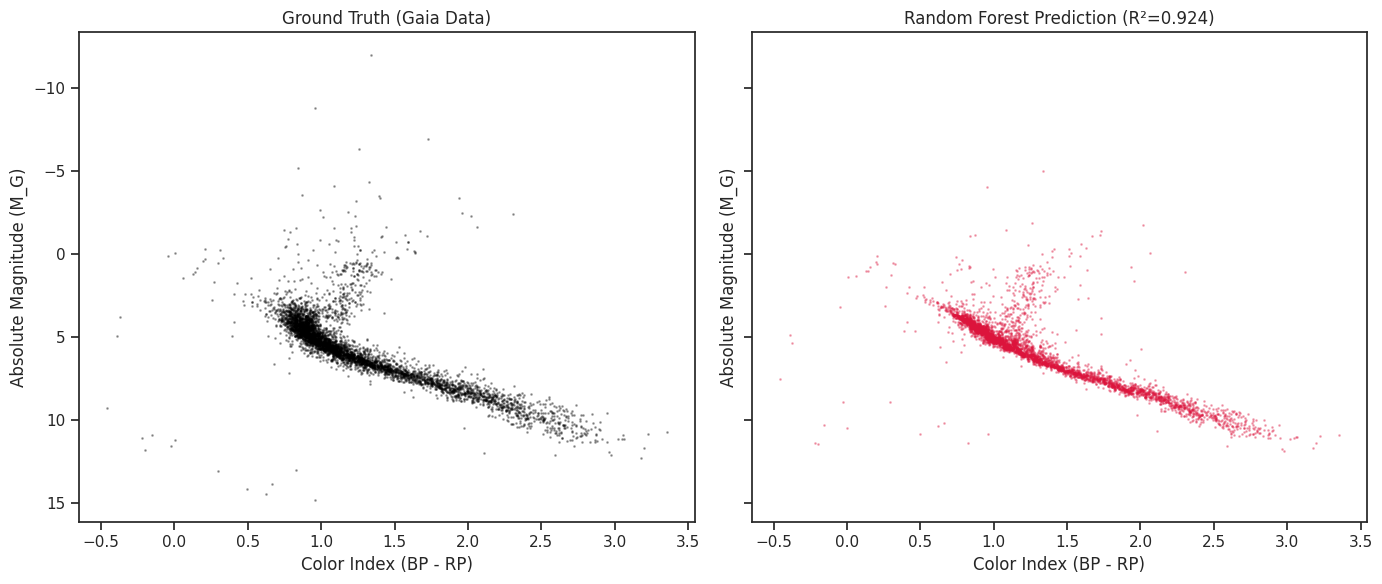

In [38]:
# Plot the Double HR Diagram
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Observed
ax1.scatter(color_index, y_true_real_scale, s=1, color='black', alpha=0.3)
ax1.set_title("Ground Truth (Gaia Data)")
ax1.invert_yaxis()

# Predicted
ax2.scatter(color_index, y_pred_real_scale, s=1, color='crimson', alpha=0.3)
ax2.set_title(f"Random Forest Prediction (R²={r2:.3f})")

for ax in [ax1, ax2]:
    ax.set_xlabel("Color Index (BP - RP)")
    ax.set_ylabel("Absolute Magnitude (M_G)")

plt.tight_layout()
plt.show()

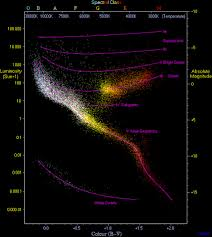

Those results are so satisfying that we are forced to define a different objective..

# 🚀 Project Summary

### 🔍 Baseline Calibration
We established that a simple **Multi-Layer Perceptron** (the `DistanceModulusNet`) can effectively "reverse-engineer" the distance modulus formula. By achieving a near-zero residual distribution, we have confirmed that our architecture is physically sound and adheres to the fundamental laws of stellar geometry.

### ⚡ The Power of Parameters
Our experimentation with learning rates and feature inclusion—specifically Apparent Magnitude ($m$) and Parallax ($p$)—demonstrated that while the model is robust, its accuracy is strictly bounded by the quality of its inputs. The network is only as precise as the astrometric data it ingests.
